# 🚀 Linear Regression Assignment: California Housing

Welcome to your Linear Regression assignment! In this notebook, you will apply what you've learned to a real-world dataset: predicting house prices in California.

### 🎯 Objective:
Build a regression model to predict the median house value for California districts based on various features (like median income, number of rooms, etc.).


---
## 📦 Step 0: Imports
Import the necessary libraries for data manipulation, visualization, and machine learning.

In [9]:
# TODO: Import pandas, numpy, matplotlib.pyplot, seaborn
# TODO: Import train_test_split, StandardScaler
# TODO: Import LinearRegression, metrics (mean_absolute_error, mean_squared_error, r2_score)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.linear_model import Ridge, Lasso

# Add your scikit-learn imports below:



---
## 1️⃣ Part 1: Data Loading & Overview
We will use the California Housing dataset built into Scikit-Learn.

In [10]:
from sklearn.datasets import fetch_california_housing

# Load the dataset
california = fetch_california_housing(as_frame=True)
df = california.frame

df.head()
# TODO: Display the first 5 rows of the dataframe



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**💡 Hint:** 
- Use `df.info()` to check for any missing values and see the data types.
- Use `df.describe()` to get a statistical summary of the features.

Our **Target Variable** is `MedHouseVal` (Median house value in $100,000s).

In [11]:
# TODO: Check data info and basic statistics

df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


---
## 2️⃣ Part 2: Exploratory Data Analysis (EDA)
Before training a model, it's crucial to understand the data's distribution and relationships.

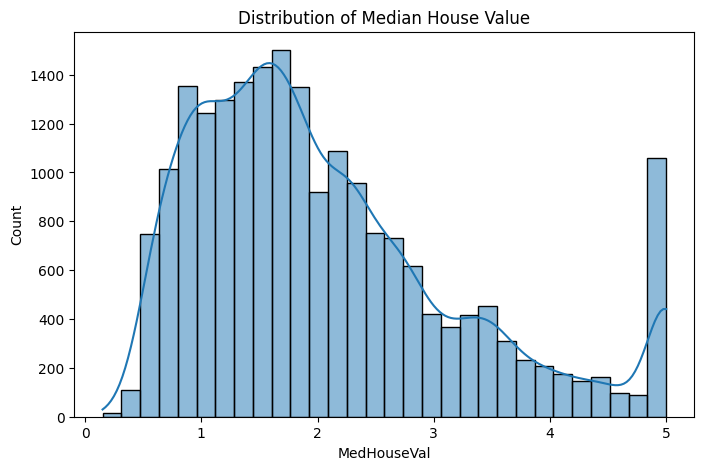

In [12]:
# TODO: Plot a histogram of the target variable (MedHouseVal)
# Hint: sns.histplot(df['MedHouseVal'], kde=True, bins=30)

plt.figure(figsize=(8, 5))
sns.histplot(df['MedHouseVal'], kde=True, bins=30)
plt.title('Distribution of Median House Value')
plt.show()

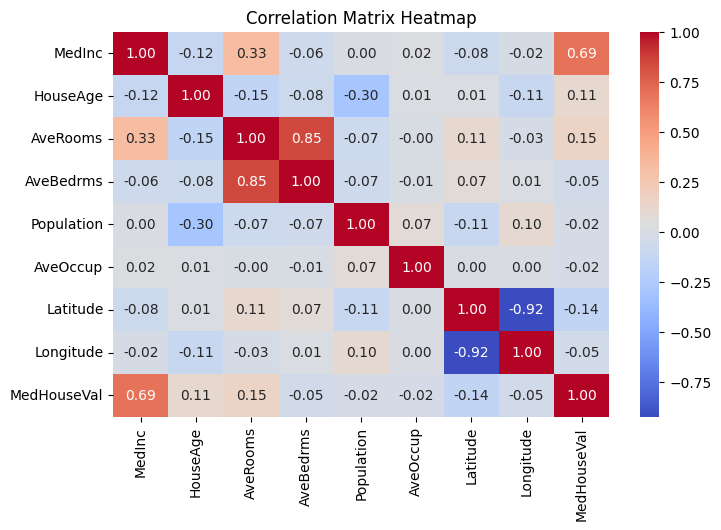

In [13]:
# TODO: Plot a correlation matrix heatmap to see which features correlate most with MedHouseVal
# Hint: plt.figure(figsize=(10, 8))
# Hint: sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

**❓ Question:** Based on the correlation matrix, which feature has the strongest positive correlation with the house value? Which one has the strongest negative correlation?

---
## 3️⃣ Part 3: Data Preprocessing
Now, let's prepare the data for our machine learning model.

In [14]:
# 1. Separate features (X) and target (y)
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# TODO: 2. Split the data into Training and Testing sets (e.g., 80% train, 20% test)
# Hint: X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**⚠️ Important:** Notice that features like `MedInc` (income) and `Population` are on completely different scales. We need to standardize them!

In [15]:
# TODO: 3. Scale the features using StandardScaler
# Hint: scaler = StandardScaler()
# Hint: X_train_scaled = scaler.fit_transform(X_train)
# Hint: X_test_scaled = scaler.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---
## 4️⃣ Part 4: Model Training
Time to train the Linear Regression model!

In [16]:
# TODO: Initialize and train the Linear Regression model
# Hint: lin_reg = LinearRegression()
# Hint: lin_reg.fit(X_train_scaled, y_train)
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


---
## 5️⃣ Part 5: Model Evaluation
Let's test our model on the unseen Test data and see how well it performs.

In [35]:
# TODO: Make predictions on the scaled test set
# Hint: y_pred = lin_reg.predict(X_test_scaled)

# TODO: Calculate and print MAE, RMSE, and R2 Score
# Hint: mae = mean_absolute_error(y_test, y_pred)
#       rmse = np.sqrt(mean_squared_error(y_test, y_pred)) 
#       r2 = r2_score(y_test, y_pred)

y_pred = lin_reg.predict(X_test_scaled)

mae = metrics.mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
r2 = metrics.r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")    

Mean Absolute Error (MAE): 0.53
Root Mean Squared Error (RMSE): 0.75
R2 Score: 0.58


---
## 🌟 Bonus / Advanced Challenge
Can you improve the error? Try using **Ridge** or **Lasso** regression to see if the R2 score goes up, or identify which features get reduced to 0 by Lasso!


In [42]:
# Try Ridge or Lasso Regression here:

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

ridge_mae = metrics.mean_absolute_error(y_test, y_pred_ridge)
Lasso_mae = metrics.mean_absolute_error(y_test, y_pred_lasso)

ridge_rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred_ridge))
Lasso_rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred_lasso))

ridge_r2 = metrics.r2_score(y_test, y_pred_ridge)
Lasso_r2 = metrics.r2_score(y_test, y_pred_lasso)

print(f"Ridge Regression - MAE: {ridge_mae:.2f}, RMSE: {ridge_rmse:.2f}, R2 Score: {ridge_r2:.2f}")
print(f"Lasso Regression - MAE: {Lasso_mae:.2f}, RMSE: {Lasso_rmse:.2f}, R2 Score: {Lasso_r2:.2f}")



Ridge Regression - MAE: 0.53, RMSE: 0.75, R2 Score: 0.58
Lasso Regression - MAE: 0.62, RMSE: 0.82, R2 Score: 0.48
